In [18]:
import scanpy as sc
from pathlib import Path
from matplotlib.collections import PathCollection
import matplotlib.pyplot as plt

In [20]:
PROJECT_ROOT = Path.cwd()
OUTPUT_DIR = PROJECT_ROOT / "figures/Quality Control"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [9]:
adata = sc.read_h5ad(PROJECT_ROOT / 'AIDA2.h5ad')

In [10]:
# mitochondrial genes
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

sc.pp.calculate_qc_metrics(adata, qc_vars=["mt", "ribo", "hb"], inplace=True, log1p=True)
adata.obs["pMito_percent"] = adata.obs["pMito"] * 100

In [11]:
import sys

print(sys.version)

3.14.6 | packaged by Anaconda, Inc. | (main, Jun 18 2026, 21:18:42) [MSC v.1942 64 bit (AMD64)]


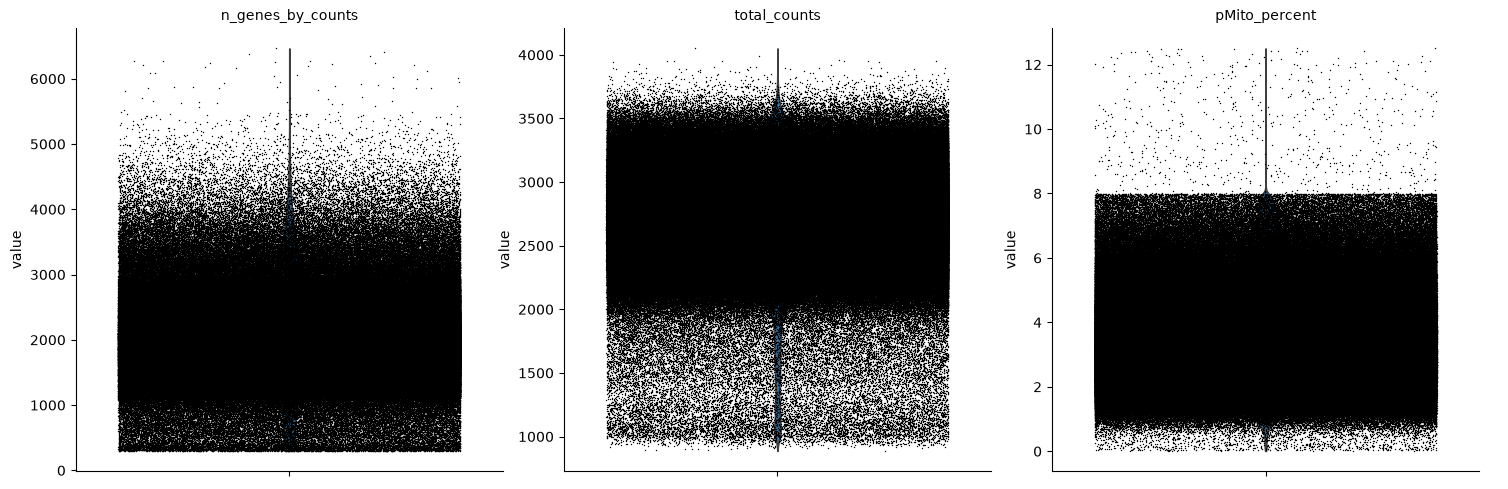

In [15]:
qc = sc.pl.violin(
    adata,
    ["n_genes_by_counts", "total_counts", "pMito_percent"],
    jitter=0.4,
    multi_panel=True,
    stripplot=True,
    show=False
)

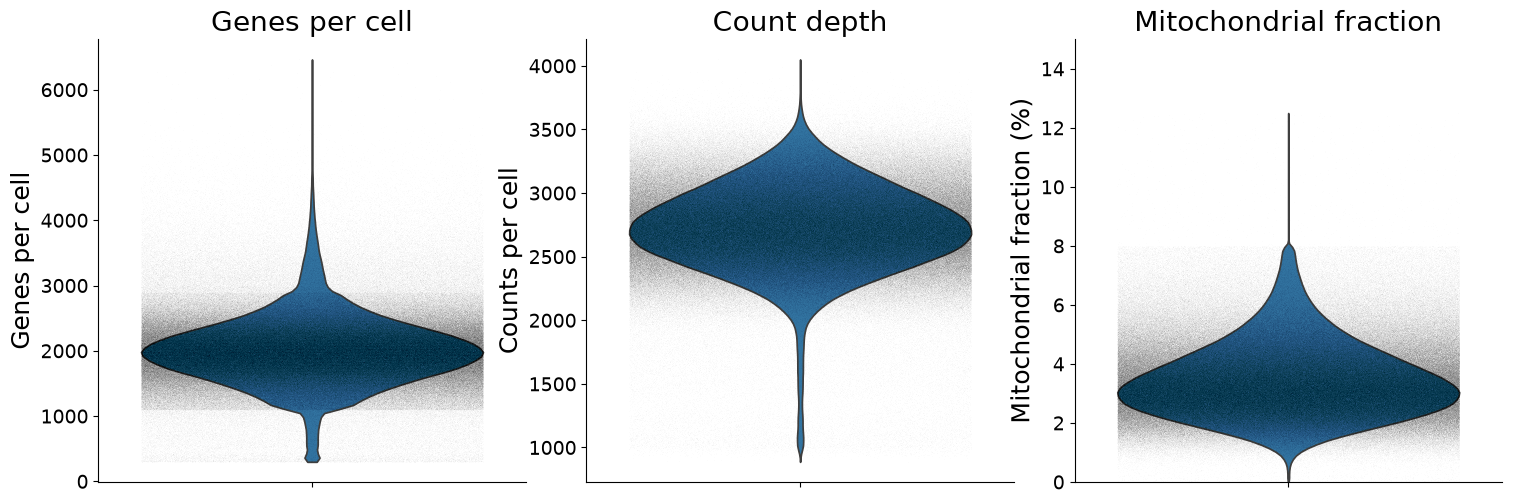

In [21]:
vars = ["n_genes_by_counts", "total_counts", "pMito_percent"]

for ax, var in zip(qc.axes.flatten(), vars):
    if var == "pMito_percent":
        ax.set_ylim(0, 15)

#Modify alpha for points
for ax in qc.axes.flatten():
    for coll in ax.collections:
        if isinstance(coll, PathCollection):
            if hasattr(coll, "get_offsets") and len(coll.get_offsets()) > 0:
                coll.set_alpha(0.0137254)

#y-axis labels
labels = ["Genes per cell", "Counts per cell", "Mitochondrial fraction (%)"]

for ax, label in zip(qc.axes.flatten(), labels):
    ax.set_ylabel(label)
    ax.set_xlabel("")

titles = ["Genes per cell", "Count depth", "Mitochondrial fraction"]

for ax, title in zip(qc.axes.flatten(), titles):
    ax.set_title(title)

for ax, title, label in zip(qc.axes.flatten(), titles, labels):
    ax.set_title(title, fontsize=20)   
    ax.set_ylabel(label, fontsize=18)       

for ax in qc.axes.flatten():
    ax.tick_params(axis='both', labelsize=14)
    
qc.fig.savefig(OUTPUT_DIR / "qc_violin.png", dpi=300, bbox_inches="tight")
display(qc.fig)
plt.close(qc.fig)

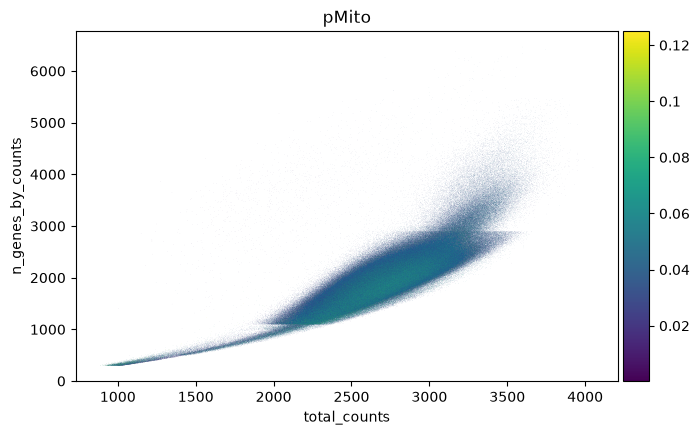

In [22]:
sc.pl.scatter(adata, "total_counts", "n_genes_by_counts", color="pMito")